shap 분석 잘 안함

비선형 모델들은 , 모델원리특성상,,,,예측보다는 분류 모형에 최적화



튜브
내가 설정한 오차 이내면 오차라고 계산하지 않음, 그게 튜브
오차에 덜 민감

꼭 직선이 아니여도 ㄱㅊ
다항식에 굉장히 강함


마진을 넒게 하는 방향으로 점점 선을 그리는거....
마진이

오차허용 > 노이즈 둔감, 일반화 성능 향상


오차를 허용하더라도 일반화가 더 잘 된다는 특징


c파라미터,,,오차를 얼마나허용할것인가 강도에 대한 데이터

공간으로 해석할 수 있어!!!! 쩐다

커널트릭 
3차원에서 면으로 쪼개서 직선처럼 보이겧 ㅏㅁ



비선형회귀에 강함 > 선형성위반에서 좋은 대체재
다항회귀로 보고값...

처음부터 다항회귀 x 최종이 scm 이면 다항회귀를 써볼만함 ㅇㅇㅇ > 2,3,차가 존재한다는 뜻


피쳐 임폴턴스~

importance mean 의누적합을 구해서...

80 같은 기준점을 정해서,,, 그 변수들로 모형을 다시 한번 더 돌려볼 수 있음


영향력


# [LAB 07] 지도학습 > 예측 > 비선형 > 02-커널기반 | SVR (Support Vector Regression)

## #01.SVR 개요
모든 점을 정확히 맞추려 하지 않고 일정 오차 안에서는 틀려도 허용하면서 가장 안정적인 회귀 함수를 찾는 모델


### [1] SVR 기본 개념
- Support Vector Machine 의 회귀 버전
- 연속형 값을 예측하는 모델
- 데이터 전체를 설명하는 하나의 함수 학습
- 전역 모형


### [2] 분류 SVM 과 예측 SVR 의 대응 관계

|구분|분류 SVM|예측 SVR|
|-|-|-|
|목표|클래스 구분|연속값 예측|
|기준|판별 경계|회귀 함수|
|핵심 개념|마진|E-튜브|
|중요 데이터|Support Vector|Support Vector|



### [3] SVR의 핵심 아이디어
- 조금 틀리는 건 괜찮다
  - 예측값과 실제값의 차이가 E 이내이면 오차로 계산하지 않음
  - 작은 오차에 덜 민감한 완만한 회귀선을 만들기 위함



### [4] E 튜브 (E-insensitive tube)
- 회귀선 주변에 허용 오차 구간을 설정
- 이 구간 안의 데이터는 손실 0
- 구간 밖의 데이터만 패널티 부여

### [5] 왜 이런 방식을 사용하는가
- 모든 점을 정확히 맞추면
  - 데이터에 과도하게 반응
  - 과적합 위험 증가
- 일정 오차를 허용하면
  - 노이즈에 둔감
  - 일반화 성능 향상




### [6] C파라미터 (오파 허용 강도)
- C는 오차를 얼마나 강하게 벌줄 것인가를 의미

|C값 | 의미|
|-|-|
|C큼|오차 거의 허용 안함 -> 회귀선 굴곡 높아짐|
|C작음|오차 헝요 -> 회귀선 부드러움|


### [7] 선형 회귀로 설명이 안되는 경우
- 직선 하나로는 데이터 패턴 설명이 불가능
- 비선형 구조 존재


### [8] 해결 전략 : 공간을 바꿔 생각
- 현재 공간에서는 직선으로 설명 불가
- 다른 공간으로 옮기면 직선 가능



### [9] 커널 트릭
- 공간을 바꿔서 선형회귀 처럼 만든다
  - 실제로 좌표를 직접 변환하지 않음
  - 거리(내적) 계산 방식만 변경
  - 고차원으로 옮긴 효과를 냄



### [10] 대표 커널 함수
|커널|설명|
|-|-|
|linear|선형관계|
|poly|곡선 관계|
|rbf|가장 많이 사용,유연함|



### [11] gamma 개념 (RBF 커널)
- 하나의 데이터가 회귀선에 미치는 영향 범위

|gamma|의미|
|-|-|
|큼|국소적 영향 -> 곡선 복잡|
|작음|전역적 영향->곡선 단순|



### [12] KNN 회귀 VS SVR 회귀 비교
|구분|KNN|SVR|
|-|-|-|
|모델 성격|국소 모형|전역 모형|
|예측 방식|주변 평균|안정적 함수|
|학습|거의 없음|최적화 수행|
|스케일링|필수|필수|
|해석|직관적|어려움|



### [13] 장단점 요약
- 장점
  - 비선형 회귀에 강함
  - 노이즈에 둔감
  - 일반화 성능 우수
- 단점
  - 파라미터에 민감
  - 해석 어려움
  - 대규모 데이터에서 느림

### [14] 최종 정리 문장
- KNN 회귀 : 비슷한 값들의 평균
- SVR 회귀 : 조금 틀려도 안정적인 선
- SVR은 정확도보다 일반화를 중시하는 예측 모델




## #02.준비 작업
### [1] 패키지 참조

In [1]:
from hossam import *

from pandas import DataFrame
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler

# 성능평가지표 모듈
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

# SVR
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance


### [2] 성능 평가 함수
#### 성능 평가 함수

In [2]:
def hs_get_scores(estimator, x_test, y_true):
    if hasattr(estimator, "named_steps"):
        classname = estimator.named_steps["model"].__class__.__name__
    else:
        classname = estimator.__class__.__name__

    y_pred = estimator.predict(x_test)

    return DataFrame(
        {
            "결정계수(R2)": r2_score(y_true, y_pred),
            "평균절대오차(MAE)": mean_absolute_error(y_true, y_pred),
            "평균제곱오차(MSE)": mean_squared_error(y_true, y_pred),
            "평균오차(RMSE)": np.sqrt(mean_squared_error(y_true, y_pred)),
            "평균 절대 백분오차 비율(MAPE)": mean_absolute_percentage_error(
                y_true, y_pred
            ),
            "평균 비율 오차(MPE)": np.mean((y_true - y_pred) / y_true * 100),
        },
        index=[classname],
    )

#### 과적합 판정 함수

In [3]:
def hs_learning_cv(
    estimator,
    x,
    y,
    scoring="neg_root_mean_squared_error",
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
):
    train_sizes, train_scores, cv_scores = learning_curve(
        estimator=estimator,
        X=x,
        y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        shuffle=True,
        random_state=52,
    )

    model_name = estimator.named_steps["model"].__class__.__name__
    print(f"=== Learning Curve: {model_name} ===")

    # neg RMSE -> RMSE
    train_rmse = -train_scores
    cv_rmse = -cv_scores

    # 평균 / 표준편차
    train_mean = train_rmse.mean(axis=1)
    cv_mean = cv_rmse.mean(axis=1)
    cv_std = cv_rmse.std(axis=1)

    # 마지막 지점 기준 값만 가져옴
    final_train = train_mean[-1]
    final_cv = cv_mean[-1]
    final_std = cv_std[-1]

    gap_ratio = final_train / final_cv
    var_ratio = final_std / final_cv

    # -------------------------
    # 과적합 기준 (some_threshold)
    # -------------------------

    # 기준 RMSE (평균 예측)
    y_mean = y.mean()
    rmse_naive = np.sqrt(np.mean((y - y_mean) ** 2))

    # 분산 기반
    std_y = y.std()

    # 최소 설명력(R2) 기반
    min_r2 = 0.10
    rmse_r2 = np.sqrt((1 - min_r2) * np.var(y))

    # 최종 threshold (가장 관대한 기준)
    some_threshold = min(rmse_naive, std_y, rmse_r2)

    # -------------------------
    # 판정 로직
    # -------------------------
    if gap_ratio >= 0.95 and final_cv > some_threshold:
        status = "🟥 과소적합 (bias 큼)"
    elif gap_ratio <= 0.8:
        status = "🟥 과적합 (variance 큼)"
    elif gap_ratio <= 0.95 and var_ratio <= 0.10:
        status = "✅ 일반화 양호"
    elif var_ratio > 0.15:
        status = "🟨 데이터 부족 / 분산 큼"
    else:
        status = "🟨 판단 유보"

    # -------------------------
    # 정량 결과 표
    # -------------------------
    result_df = DataFrame(
        {
            "지표": [
                "Train RMSE",
                "CV RMSE 평균",
                "CV RMSE 표준편차",
                "Train/CV 비율",
                "CV 변동성 비율",
                "판정 결과",
            ],
            "값": [
                final_train,
                final_cv,
                final_std,
                gap_ratio,
                var_ratio,
                status,
            ],
        }
    )

    display(result_df)

    # -------------------------
    # 학습곡선 시각화
    # -------------------------
    figsize = (1280 / my_dpi, 720 / my_dpi)
    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

    sb.lineplot(
        x=train_sizes,
        y=train_mean,
        marker="o",
        markeredgecolor="#ffffff",
        label="Train RMSE",
    )

    sb.lineplot(
        x=train_sizes,
        y=cv_mean,
        marker="o",
        markeredgecolor="#ffffff",
        label="CV RMSE",
    )

    ax.set_xlabel("학습 데이터 크기", fontsize=8, labelpad=5)
    ax.set_ylabel("RMSE (Learning Curve)", fontsize=8, labelpad=5)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.close()


### [3] 데이터 가져오기 + 인덱스,타입 변환

In [4]:
origin = load_data("restaurant_sales_preprocessed")
origin.set_index("date", inplace=True)
origin["holiday"] = origin["holiday"].astype("category")
origin["weekend"] = origin["weekend"].astype("category")
origin.info()


어느 식당의 1년간 일별 매출을 기록한 데이터의 전처리 완료 버전(명목형이 이진변수만 있으므로 더미변수는 처리하지 않음)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 353 entries, 2024-01-01 to 2024-12-30
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   sales           353 non-null    float64 
 1   visitors        353 non-null    int64   
 2   avg_price       353 non-null    int64   
 3   marketing_cost  353 non-null    float64 
 4   delivery_ratio  353 non-null    float64 
 5   rain_mm         353 non-null    float64 
 6   temperature     353 non-null    float64 
 7   holiday         353 non-null    category
 8   weekend         353 non-null    category
dtypes: category(2), float64(5), int64(2)
memory usage: 23.0 KB


### [4] 훈련, 검증 데이터 분리

In [ ]:
df = origin

yname = "sales"
x = df.drop(columns=[yname])
y = df[yname]

x_train, test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=52
)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((264, 8), (89, 8), (264,), (89,))

## #03. SVR 모델 적합
### [1] 주요 하이퍼 파라미터



| 파라미터명 | 핵심도 | 설명 | 기본값 | GridSearchCV 권장 값 |
|-----------|--------|------|--------|----------------------|
| kernel | ⭐⭐⭐ | 커널 종류 (비선형 표현 방식) | `'rbf'` | `['linear', 'rbf', 'poly']` |
| C | ⭐⭐⭐ | 오차 패널티 강도 (bias-variance 적정 제어) | `1.0` | `[0.1, 1, 10, 100]` |
| epsilon | ⭐⭐ | ε-튜브 폭 (오차 무시 범위) | `0.1` | `[0.01, 0.05, 0.1, 0.2, 0.5]` |
| gamma | ⭐⭐ | 데이터 1개 영향 범위 (RBF/Poly) | `'scale'` | `['scale', 'auto', 0.01, 0.1, 1]` |
| degree | ⭐ | 다항 커널 차수 (`kernel='poly'`) | `3` | `[2, 3, 4]` |
| coef0 | ⭐ | 다항·시그모이드 커널 보정항 | `0.0` | `[0.0, 0.5, 1.0]` |
| shrinking | ⭐ | 최적화 속도 개선 옵션 | `True` | `[True, False]` |
| tol | ⭐ | 수렴 허용 오차 | `1e-3` | `[1e-4, 1e-3]` |
| max_iter | ✅ | 최대 반복 횟수 | `-1` | `-1` |
| cache_size | ✅ | 커널 캐시 메모리(MB) | `200` | `200` |


### [2] 모형 적합

In [6]:
%time

# 파이프라인 정의
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR())
])

# 하이퍼파라미터 그리드
param_grid = {
    # 핵심 파라미터 ⭐⭐⭐
    "model__kernel": ["rbf"],          # 수업·실습 기본은 rbf 고정
    "model__C": [0.1, 1, 10, 100],
    "model__epsilon": [0.01, 0.05, 0.1, 0.2],
    "model__gamma": ["scale", "auto", 0.01, 0.1, 1],

    # poly 커널 확장 (필요 시만 사용, 학습속도 매우 느려짐) ⭐⭐
    # "model__kernel": ["poly"],
    # "model__degree": [2, 3, 4],
    # "model__coef0": [0.0, 0.5, 1.0],
}

# GridSearchCV 설정
gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)

# 학습
gs.fit(x_train, y_train)

# 최적 모델
best_model = gs.best_estimator_

# 결과 확인
print("Best params:", gs.best_params_)
print("CV best score:", gs.best_score_)


CPU times: total: 0 ns
Wall time: 5.01 μs
Best params: {'model__C': 1, 'model__epsilon': 0.1, 'model__gamma': 0.01, 'model__kernel': 'rbf'}
CV best score: 0.689458074664535


## #04.성능평가
### [1] 성능평가 지표

In [7]:
hs_get_scores(best_model,x_test,y_test)

,결정계수(R2),평균절대오차(MAE),평균제곱오차(MSE),평균오차(RMSE),평균 절대 백분오차 비율(MAPE),평균 비율 오차(MPE)
SVR,0.700852,0.15744,0.042795,0.206868,0.009578,0.233363


#### 지금까지 살펴본 다른 모형들의 성능

| 모델           | 결정계수 (R²) | 평균절대오차 (MAE) | 평균제곱오차 (MSE) | 평균오차 (RMSE) | 평균 절대 백분오차 비율 (MAPE) | 평균 비율 오차 (MPE) |
| ------------ | --------- | ------------ | ------------ | ----------- | -------------------- | -------------- |
| Linear       | 0.709     | 0.156        | 0.042        | 0.204       | 0.010                | 0.225          |
| Ridge        | 0.708     | 0.156        | 0.042        | 0.205       | 0.010                | 0.219          |
| Lasso        | 0.707     | 0.155        | 0.042        | 0.205       | 0.009                | 0.221          |
| ElasticNet   | 0.709     | 0.156        | 0.042        | 0.204       | 0.010                | 0.223          |
| SGD          | 0.697     | 0.160        | 0.043        | 0.208       | 0.010                | 0.260          |
| KNN          | 0.635     | 0.178        | 0.052        | 0.229       | 0.011                | 0.301          |
| DecisionTree | 0.620     | 0.196        | 0.054        | 0.233       | 0.012                | 0.353          |


### [2] 과적합 판정

=== Learning Curve: SVR ===


,지표,값
0,Train RMSE,0.195903
1,CV RMSE 평균,0.206466
2,CV RMSE 표준편차,0.011258
3,Train/CV 비율,0.948842
4,CV 변동성 비율,0.054525
5,판정 결과,✅ 일반화 양호


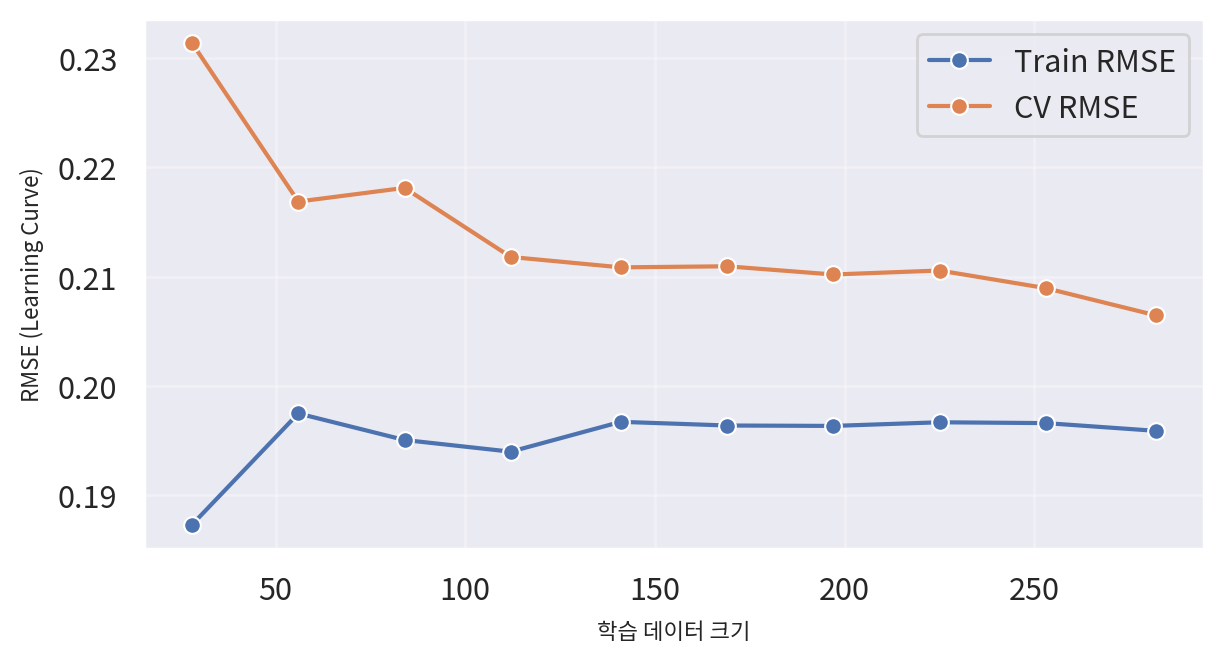

In [8]:
hs_learning_cv(best_model,x,y)

## #05.모델 설명
### [1] 변수 중요도 확인 함수
- 향후 XGBoost 와 LightGBM 에서 코드 추가/개선됨

In [9]:
from sklearn.inspection import permutation_importance

def feature_importance(model, x, y):
    perm = permutation_importance(
        estimator=model,
        X=x,
        y=y,
        scoring="r2",
        n_repeats=30,
        random_state=42,
        n_jobs=-1,
    )

    # 결과 정리
    perm_df = DataFrame(
        {
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std,
        },
        index=x.columns,
    ).sort_values("importance_mean", ascending=False)

    # 시각화
    df = perm_df.sort_values(by="importance_mean", ascending=False)

    figsize = (1280 / my_dpi, 600 / my_dpi)
    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

    sb.barplot(data=df, x="importance_mean", y=df.index)

    ax.set_title("Permutation Importance")
    ax.set_xlabel("Permutation Importance (mean)")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.close()

    return perm_df


### [2] 변수 중요도 확인

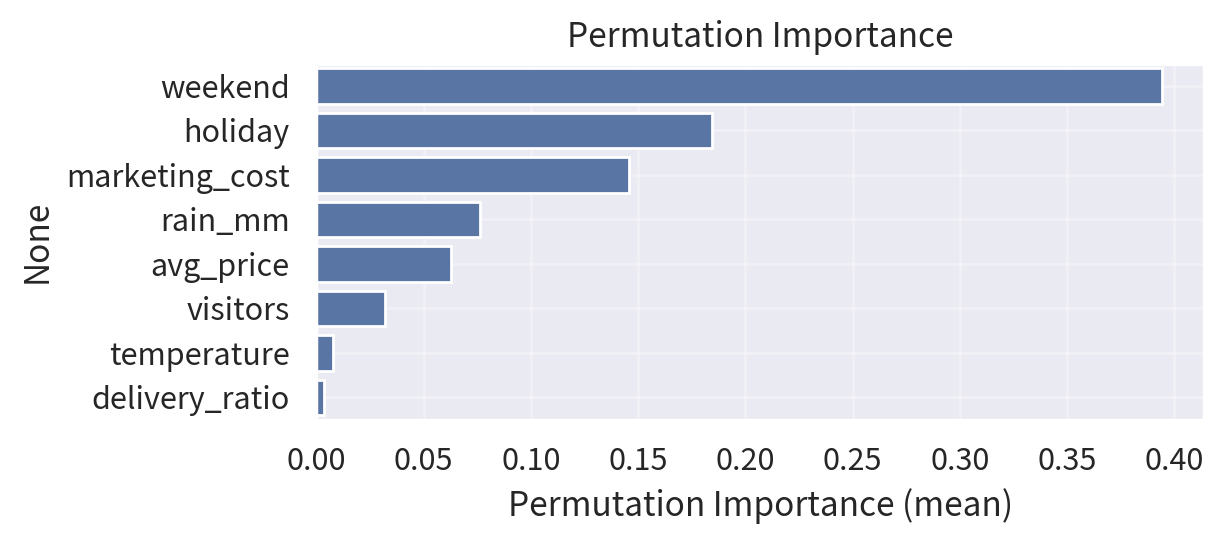

,importance_mean,importance_std
weekend,0.394110,0.043869
holiday,0.184326,0.024400
marketing_cost,0.145813,0.023426
rain_mm,0.076316,0.013030
avg_price,0.062934,0.011333
visitors,0.031952,0.007406
temperature,0.007668,0.002362
delivery_ratio,0.003617,0.001869


In [10]:
fi = feature_importance(best_model,x_train,y_train)
fi

#### 인사이트
## ✏️ 인사이트

### 🎯 주요 영향 변수

* **weekend (주말 여부)**가 `0.355`로 가장 높은 영향력으로 매출 예측의 핵심 요인
* 평일 vs 주말의 판매 패턴 차이가 매우 큼을 의미

### 📊 중요도 상위 4개 변수의 누적 기여도

* `weekend(0.355) + holiday(0.167) + marketing_cost(0.146) + rain_mm(0.116) = 0.784`
* 상위 4개 변수가 전체 변동성의 **약 78%를 설명**

### 🕒 시간적/이벤트 요인의 중요성

* `weekend(0.355) + holiday(0.167) = 0.522` → 시간 패턴이 매출의 절반 이상을 결정
* 외부 달력 이벤트(주말/휴일)가 영업 전략의 핵심

### 💰 마케팅 비용의 실질적 영향

* `marketing_cost`가 `0.146`으로 세 번째 주요 변수
* 마케팅 투자가 매출 증대에 **유의미한 기여도**가 있음을 확인

### 🌧 날씨 부분적 영향

* `rain_mm(0.116)`은 중간 수준의 영향력 보유
* 강우량이 고객 방문 패턴에 영향을 미치는 것으로 해석

### 🔍 무시해도 되는 변수들

* `temperature(-0.002)`, `delivery_ratio(0.002)`, `visitors(0.014)`는 거의 영향력 없음
* 모델 단순화 시 제거 가능한 변수들

### ⚠️ 모델의 불안정성 신호

* 모든 변수의 `importance_std(표준편차)`가 존재 → 크로스밸리데이션 과정에서 변동이 있었음을 의미
* `weekend`의 `std`가 `0.064`로 상대적으로 높음 → 주말 효과 해석 시 주의 필요
